Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.


Datasets :

Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [87]:
# load dataset
import pandas as pd
df=pd.read_excel('/content/EastWestAirlines.xlsx',sheet_name='data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [88]:
# checking for missing values
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [89]:
# checking for duplicates
df.duplicated().any()

False

<Axes: >

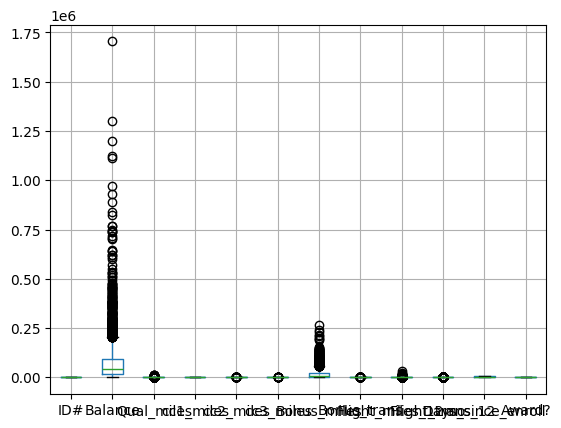

In [90]:
# checking for outliers
df.boxplot()

In [91]:
# outlier capping
def outlier_capping(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[column]=df[column].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)
for i in df.select_dtypes(include=['float','int']):
  outlier_capping(df,i)

In [92]:
# remove unneccessary columns
df.drop(columns=['ID#','Award?'],inplace=True)

In [93]:
# scaling
from sklearn.preprocessing import StandardScaler
sta_sca=StandardScaler()
df=pd.DataFrame(sta_sca.fit_transform(df),columns=df.columns)
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975


<Axes: >

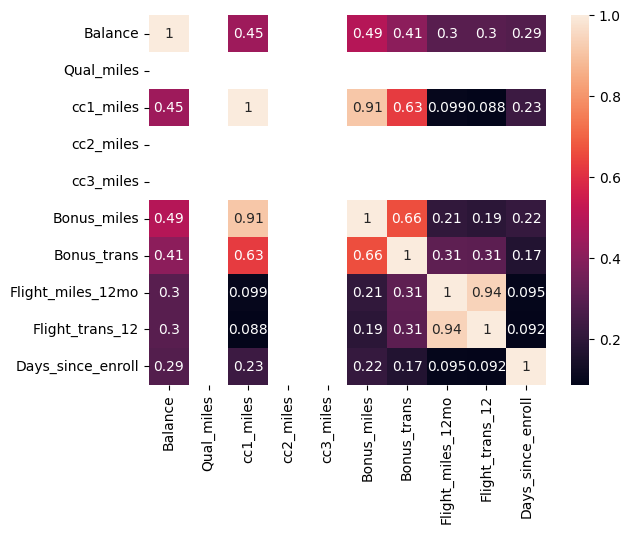

In [94]:
#correlation
import seaborn as sns
corr=df.corr()
sns.heatmap(corr,annot=True)

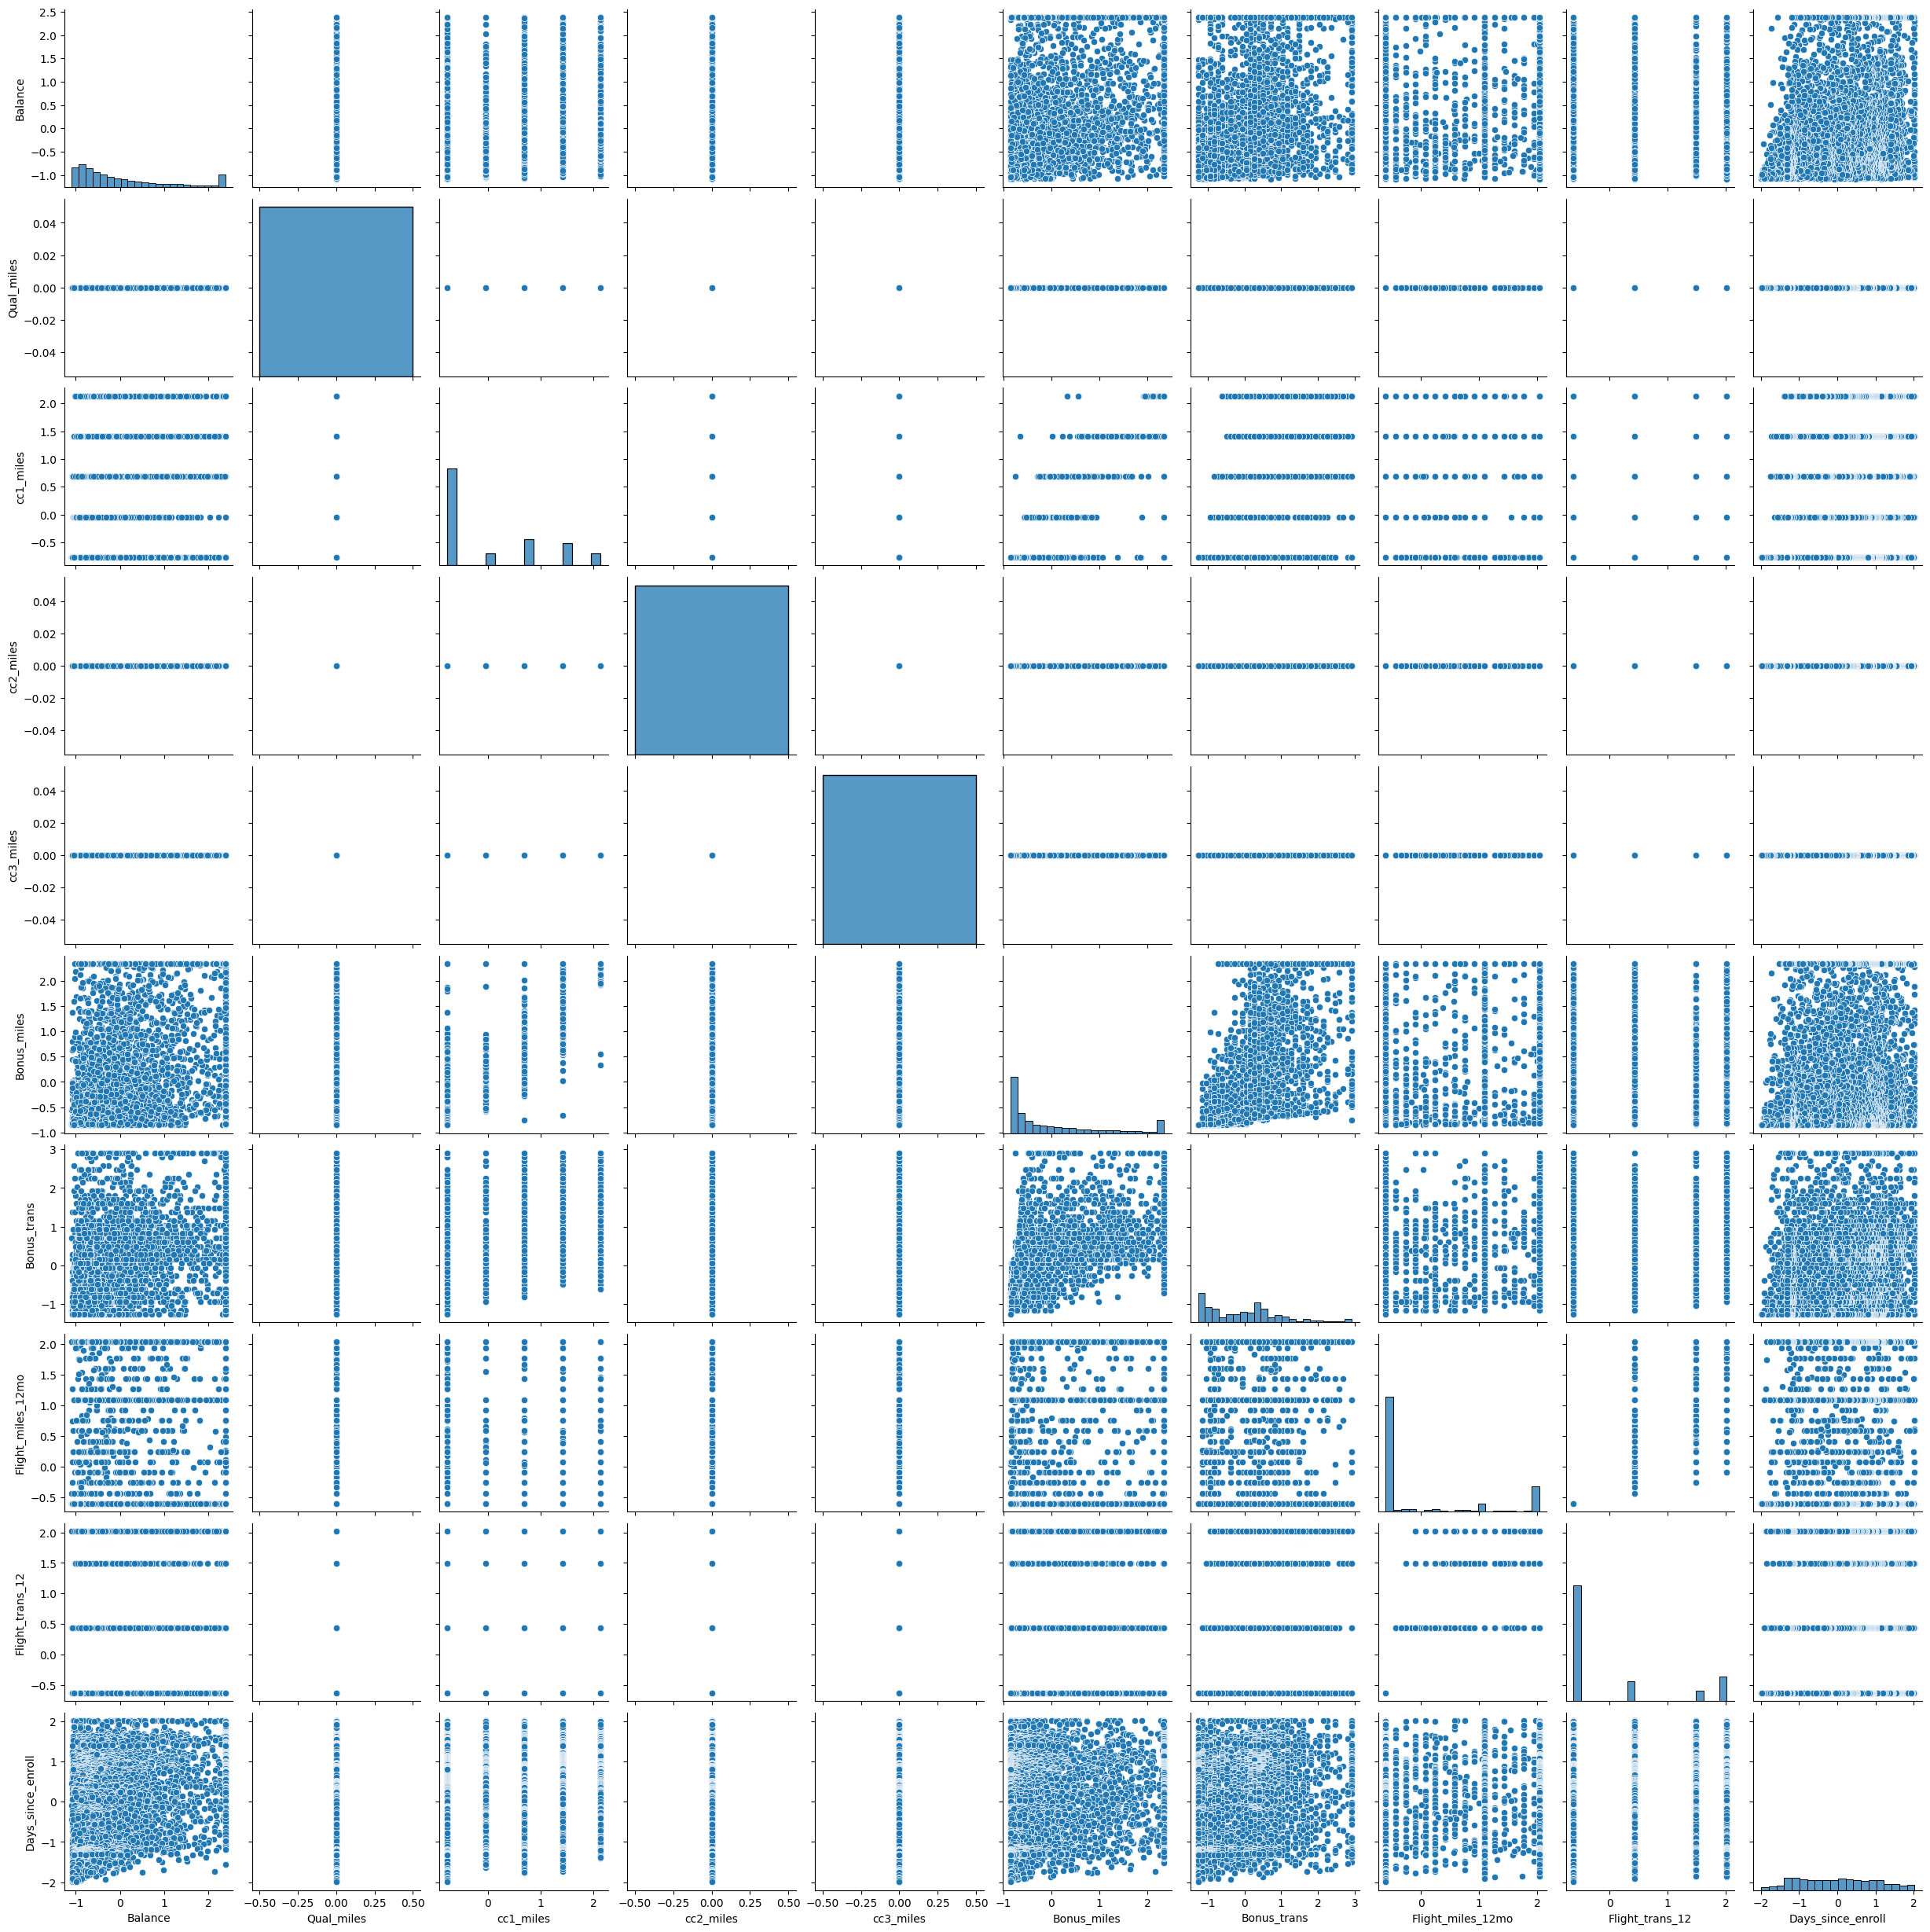

In [95]:
sns.pairplot(df)

<Axes: ylabel='Count'>

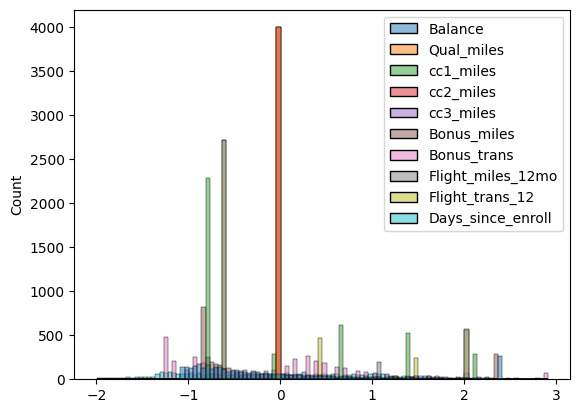

In [96]:
sns.histplot(df)

Implementing Clustering Algorithms:

•	Implement the K-Means, hierarchical, and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for hierarchical clustering (e.g., linkage criteria), K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


In [97]:
# KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [98]:
kmeans=KMeans(n_clusters=2)

In [99]:
kmeans.fit(df)

KMeans(n_clusters=2)

In [100]:
import numpy as np
np.unique(kmeans.labels_)

array([0, 1], dtype=int32)

In [101]:
kmeans.cluster_centers_

array([[ 0.80932979,  0.        ,  1.07394072,  0.        ,  0.        ,
         1.10954799,  0.90507109,  0.50010854,  0.48333591,  0.40524071],
       [-0.40786082,  0.        , -0.54121119,  0.        ,  0.        ,
        -0.55915544, -0.45610954, -0.25202912, -0.24357658, -0.20422059]])

In [102]:
silhouette_score(df,kmeans.labels_)

0.3417901698322852

In [103]:
# Elbow method
inertia=[]
for i in range(1,11):
  kmeans1=KMeans(n_clusters=i)
  kmeans1.fit(df)
  inertia.append(kmeans1.inertia_)
print(inertia)

[27992.99999999999, 18910.884955770907, 14316.216153683126, 11942.751591212167, 10451.08890601983, 9415.161592084436, 9167.27569360887, 8143.184302202391, 8065.80443476522, 7305.26277530192]


Text(0, 0.5, 'Inertia')

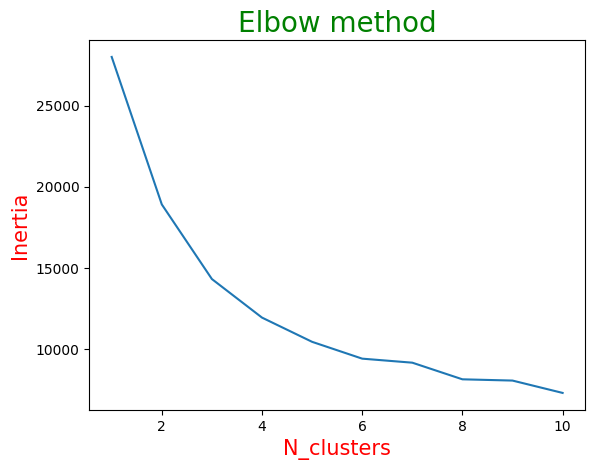

In [104]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),inertia)
plt.title('Elbow method',size=20,color='green')
plt.xlabel('N_clusters',size=15,color='red')
plt.ylabel('Inertia',size=15,color='red')

In [105]:
kmeans2=KMeans(n_clusters=6)
kmeans2.fit(df)

KMeans(n_clusters=6)

In [106]:
silhouette_score(df,kmeans2.labels_)

0.268538171591948

In [107]:
kmeans3=KMeans(n_clusters=4)
kmeans3.fit(df)

KMeans(n_clusters=4)

In [108]:
silhouette_score(df,kmeans3.labels_)

0.3411776895124208

In [109]:
#Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

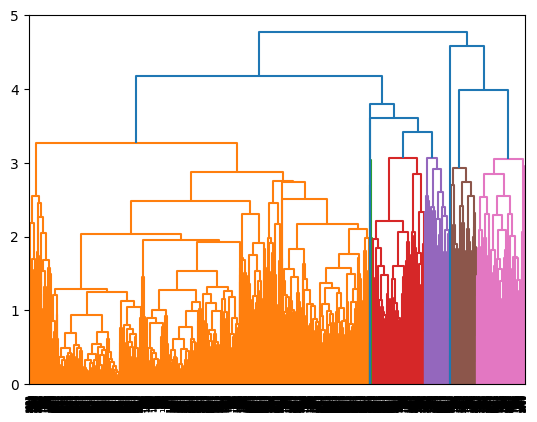

In [110]:
dendrogram=sch.dendrogram(sch.linkage(df,method='average'))

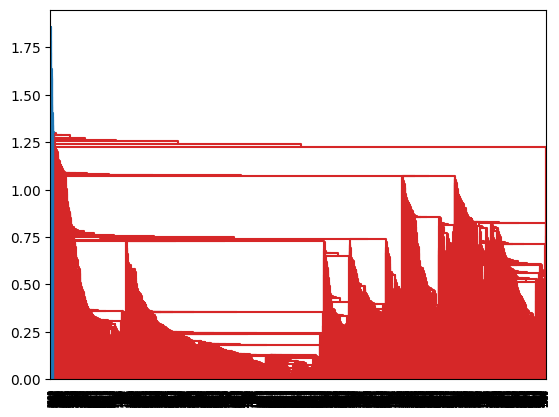

In [111]:
dendrogram=sch.dendrogram(sch.linkage(df,method='single'))

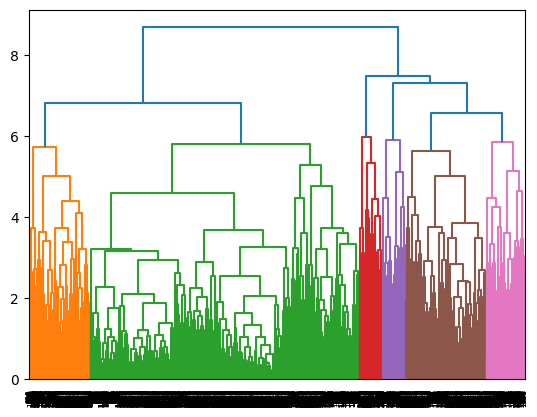

In [112]:
dendrogram=sch.dendrogram(sch.linkage(df,method='complete'))

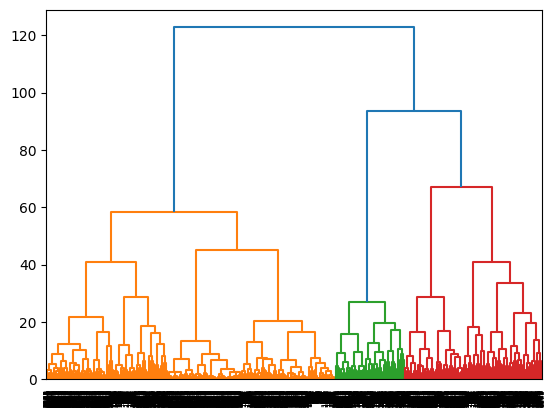

In [113]:
dendrogram=sch.dendrogram(sch.linkage(df,method='ward'))

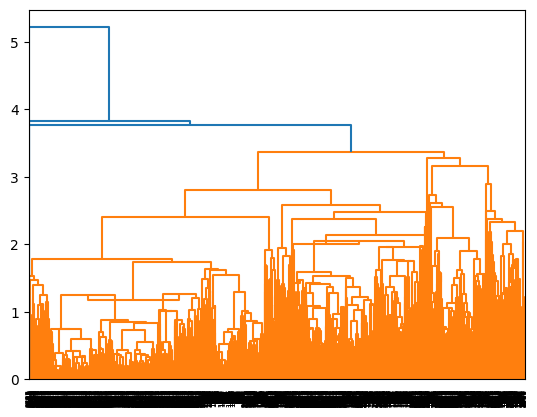

In [114]:
dendrogram=sch.dendrogram(sch.linkage(df,method='centroid'))

In [115]:
agg1=AgglomerativeClustering(n_clusters=2,linkage='average')
cluster1=agg1.fit(df)

In [116]:
agg2=AgglomerativeClustering(n_clusters=2,linkage='single')
cluster2=agg2.fit(df)

In [117]:
agg3=AgglomerativeClustering(n_clusters=2,linkage='complete')
cluster3=agg3.fit(df)

In [118]:
agg4=AgglomerativeClustering(n_clusters=2,linkage='ward')
cluster4=agg4.fit(df)

In [119]:
# DBSCAN
from sklearn.cluster import DBSCAN

In [120]:
labels=DBSCAN(eps=0.2,min_samples=4).fit(df).labels_

In [121]:
labels1=DBSCAN(eps=0.1,min_samples=10).fit(df).labels_

In [122]:
labels2=DBSCAN(eps=0.3,min_samples=5).fit(df).labels_

Cluster Analysis and Interpretation:

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.



In [123]:
# Kmeans
kmeans.cluster_centers_

array([[ 0.80932979,  0.        ,  1.07394072,  0.        ,  0.        ,
         1.10954799,  0.90507109,  0.50010854,  0.48333591,  0.40524071],
       [-0.40786082,  0.        , -0.54121119,  0.        ,  0.        ,
        -0.55915544, -0.45610954, -0.25202912, -0.24357658, -0.20422059]])

In [124]:
kmeans.labels_

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [125]:
cluster1.labels_

array([1, 1, 1, ..., 1, 1, 1])

In [126]:
labels

array([ 0,  0, -1, ..., -1, -1,  0])

In [127]:
'''
KMeans Clustering & Hierarchical clustering:
cluster 0= not awarded
cluster 1=awarded

DBSCAN:
cluster -1: outlier
'''

'\nKMeans Clustering & Hierarchical clustering:\ncluster 0= not awarded\ncluster 1=awarded\n\nDBSCAN:\ncluster -1: outlier\n'

Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.


In [128]:
#Kmeans
from sklearn.decomposition import PCA

In [129]:
pca=PCA(n_components=2)

In [130]:
pca.fit(df)

PCA(n_components=2)

In [131]:
features=pca.transform(df)

In [132]:
kmeans_pca=KMeans(n_clusters=2)

In [133]:
kmeans_pca.fit(features)

KMeans(n_clusters=2)

In [134]:
df2=pd.DataFrame(features)
df2=df2.rename(columns={0:'pca1',1:'pca2'})
df2.head()


,pca1,pca2
0,-1.584423,-0.195228
1,-1.596551,-0.202092
2,-1.246402,-0.306007
3,-1.668127,-0.191096
4,3.829973,1.176550


In [135]:
df2['clusters']=kmeans_pca.labels_

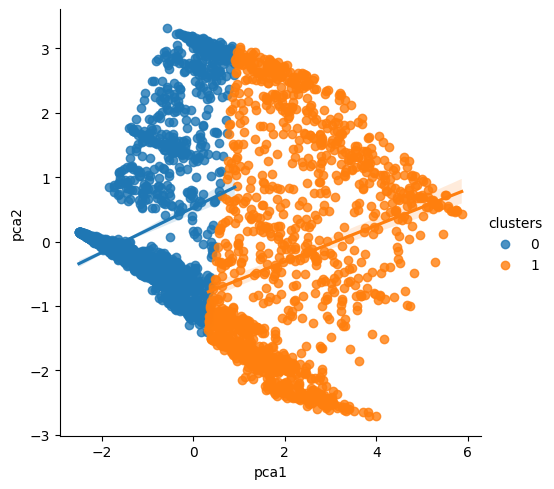

In [136]:
sns.lmplot(data=df2,x='pca1',y='pca2',hue='clusters')

In [137]:
#DBSCAN
label_pca=DBSCAN(eps=0.2,min_samples=7).fit(df2).labels_

<Axes: xlabel='pca1', ylabel='pca2'>

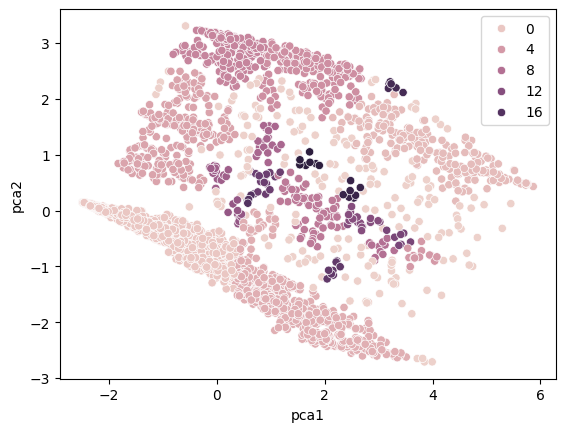

In [138]:
sns.scatterplot(data=df2,x='pca1',y='pca2',hue=label_pca)

In [139]:
import plotly.express as pe
pe.scatter(df2,x='pca1',y='pca2',color=label_pca)

Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN


In [140]:
from sklearn.metrics import silhouette_score

In [141]:
#Kmeans
silhouette_score(df2,kmeans_pca.labels_)

0.49901018442445855

In [142]:
#Hierarchical clustering
silhouette_score(df,cluster1.labels_)

0.34467606659270833

In [143]:
#DBSCAN
silhouette_score(df2,label_pca)

0.24916195268484848